In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.gridspec as gridspec

def spectral_clustering_analysis(
    features_data,
    velocity_value,
    selected_features=None,  
    feature_type='spatter',
    threshold=50,
    standardize=True,
    csv_path='./regimes/Experimental_parameters.csv',
    random_state=42
):
    """
    Perform spectral clustering on data for a specific velocity to identify
    conduction vs. keyhole modes.

    Args:
        features_data (dict): The hierarchical features dictionary
        velocity_value (float): The velocity to filter for
        selected_features (list): List of feature names to use for clustering. If None, use all features
        feature_type (str): Either 'spatter' or 'area'
        threshold (int): Threshold for area features
        standardize (bool): Whether to standardize features
        csv_path (str): Path to parameters CSV file
        random_state (int): Random seed for reproducibility

    Returns:
        matplotlib.figure.Figure: The generated figure
    """
    # Input validation
    if feature_type not in ['spatter', 'area']:
        raise ValueError("feature_type must be either 'spatter' or 'area'")

    # Step 1: Extract data for the specified velocity
    rows = []
    for cube, condition, line in product(
        features_data.keys(),
        features_data[1].keys(),
        features_data[1][1].keys()
    ):
        try:
            # Get power and velocity for this combination
            velocity, power = get_velocity_power(cube, condition, csv_path)

            # Filter by velocity
            if velocity != velocity_value:
                continue

            # Get features
            if feature_type == 'spatter':
                features = features_data[cube][condition][line]['spatter']
            else:  # area
                features = features_data[cube][condition][line]['area'][threshold]

            # Add row with features and parameters
            row = {
                'cube': cube,
                'condition': condition,
                'line': line,
                'power': power,
                'velocity': velocity,
                **features
            }
            rows.append(row)
        except KeyError:
            continue

    df = pd.DataFrame(rows)

    if df.empty:
        raise ValueError(f"No data found for velocity={velocity_value}")

    if len(df) < 3:
        raise ValueError(f"Not enough data points for clustering (found {len(df)})")

    # Step 2: Prepare feature matrix
    all_feature_cols = [col for col in df.columns
                       if col not in ['cube', 'condition', 'line', 'velocity']]  

    # Use selected features if provided, otherwise use all features
    if selected_features is not None:
        # Add power to selected features if not already included
        if 'power' not in selected_features:
            feature_cols = selected_features + ['power']
        else:
            feature_cols = selected_features

        # Validate selected features
        invalid_features = [f for f in feature_cols if f not in all_feature_cols]
        if invalid_features:
            raise ValueError(f"Invalid features: {invalid_features}")
    else:
        feature_cols = all_feature_cols  

    X = df[feature_cols].values

    # Step 3: Standardize if requested
    if standardize:
        scaler = StandardScaler()
        X = scaler.fit_transform(X)

    # Step 4: Apply spectral clustering
    clustering = SpectralClustering(
        n_clusters=2,
        assign_labels='discretize',
        random_state=random_state
    ).fit(X)
    
    print(X)

    # Step 5: Assign labels to df
    df['cluster'] = clustering.labels_

    # Step 6: Determine which cluster is conduction vs keyhole based on average power
    cluster_power_means = df.groupby('cluster')['power'].mean()
    conduction_cluster = cluster_power_means.idxmin()
    keyhole_cluster = 1 - conduction_cluster

    df['mode'] = df['cluster'].map({
        conduction_cluster: 'Conduction',
        keyhole_cluster: 'Keyhole'
    })

    # Step 7: Create visualizations
    fig = plt.figure(figsize=(16, 16))
    gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], width_ratios=[1, 1])

    df = df.sort_values('power')

    # 7.1: t-SNE Plot
    ax1 = plt.subplot(gs[0, 0])
    tsne = TSNE(n_components=2, random_state=random_state)
    X_tsne = tsne.fit_transform(X)

    for mode in ['Conduction', 'Keyhole']:
        mask = df['mode'] == mode
        scatter = ax1.scatter(
            X_tsne[mask, 0],
            X_tsne[mask, 1],
            c=df.loc[mask, 'power'],
            cmap='coolwarm',
            s=100,
            alpha=0.8,
            edgecolor='k',
            label=mode
        )

    plt.colorbar(scatter, ax=ax1, label='Power (W)')
    ax1.set_title(f't-SNE Visualization for Velocity = {velocity_value} mm/s', fontsize=14)
    ax1.set_xlabel('t-SNE Dimension 1')
    ax1.set_ylabel('t-SNE Dimension 2')
    ax1.legend()

    # 7.2: PCA Plot
    ax2 = plt.subplot(gs[0, 1])
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    for mode in ['Conduction', 'Keyhole']:
        mask = df['mode'] == mode
        scatter = ax2.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            c=df.loc[mask, 'power'],
            cmap='coolwarm',
            s=100,
            alpha=0.8,
            edgecolor='k',
            label=mode
        )

    plt.colorbar(scatter, ax=ax2, label='Power (W)')
    ax2.set_title(f'PCA Visualization for Velocity = {velocity_value} mm/s', fontsize=14)
    ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
    ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
    ax2.legend()

    # 7.3: Power vs. Cluster Plot
    ax3 = plt.subplot(gs[1, 0])
    sns.stripplot(
        data=df,
        x='power',
        y='mode',
        hue='mode',
        palette={'Conduction': 'blue', 'Keyhole': 'red'},
        size=10,
        jitter=True,
        alpha=0.7,
        ax=ax3,
        legend=False
    )
    ax3.set_title(f'Clustering Results by Power for Velocity = {velocity_value} mm/s', fontsize=14)
    ax3.set_xlabel('Power (W)')
    ax3.set_ylabel('Process Mode')

    # 7.4: Feature Comparison Grid
    n_features = len(feature_cols)
    n_cols_features = min(4, n_features)
    n_rows_features = (n_features + n_cols_features - 1) // n_cols_features

    gs_features = gridspec.GridSpecFromSubplotSpec(
        n_rows_features, n_cols_features,
        subplot_spec=gs[1, 1],
        hspace=0.4,
        wspace=0.3
    )

    for i, feature in enumerate(feature_cols):
        row, col = divmod(i, n_cols_features)
        ax = plt.subplot(gs_features[row, col])

        if standardize:
            feature_data = df[feature]
            feature_data = (feature_data - feature_data.mean()) / feature_data.std()
        else:
            feature_data = df[feature]

        sns.boxplot(
            data=df,
            x='mode',
            y=feature,
            hue='mode',
            palette={'Conduction': 'blue', 'Keyhole': 'red'},
            legend=False,
            ax=ax
        )

        ax.set_title(feature, fontsize=10, pad=5)
        ax.set_xlabel('')
        if col == 0:
            ax.set_ylabel('Value', fontsize=10)
        else:
            ax.set_ylabel('')

        ax.tick_params(axis='x', rotation=45)
        ax.tick_params(axis='both', labelsize=8)

    plt.suptitle(
        f'Spectral Clustering Analysis for {feature_type.capitalize()} Features' +
        (f' (Threshold {threshold})' if feature_type == 'area' else '') +
        f'\nVelocity = {velocity_value} mm/s' +
        f'\nUsing {len(feature_cols)} features',
        fontsize=16,
        y=1
    )

    plt.subplots_adjust(
        top=0.92,
        bottom=0.08,
        left=0.08,
        right=0.92,
        hspace=0.25,
        wspace=0.2
    )

    return fig



In [2]:
import pandas as pd

def get_velocity_power(cube, condition, csv_path='./regimes/Experimental_parameters.csv'):
    """
    Get velocity and power parameters for a given cube and condition.
    
    Args:
        cube (int): Cube number (1-4)
        condition (int): Condition number (1-12)
        csv_path (str): Path to the parameters CSV file
        
    Returns:
        tuple: (velocity (mm/s), power (W))
        
    Raises:
        ValueError: If cube or condition are out of valid ranges
        FileNotFoundError: If CSV file cannot be found
    """
    # Input validation
    if not 1 <= cube <= 4:
        raise ValueError("Cube number must be between 1 and 4")
    if not 1 <= condition <= 12:
        raise ValueError("Condition number must be between 1 and 12")
    
    # Read CSV file
    params_df = pd.read_csv(csv_path)
    
    # Calculate row index
    row_index = (cube - 1) * 12 + (condition - 1)
    
    # Get parameters
    velocity = params_df.iloc[row_index]['Velocity']
    power = params_df.iloc[row_index]['Power']
    
    return velocity, power

In [3]:
import pickle
# Load data
with open('extracted_features.pickle', 'rb') as f:
    features_data = pickle.load(f)

In [4]:
selected_features = None

[[ 1.01388955e+00  1.36207732e-01 -3.78088461e-02  1.13611667e-01
   8.34427335e-02 -9.16999306e-01 -1.26013692e+00  5.87564770e-01
  -2.18195604e-01 -7.45523019e-01  8.39780618e-01  3.79323692e-01
   8.48783640e-01 -6.26262754e-01 -5.83101949e-02]
 [ 1.01388955e+00  2.03378668e-01  1.06829022e-01 -5.57473398e-02
  -6.99240879e-02 -4.34431389e-01 -5.76048784e-01  1.36555565e-01
  -4.28026895e-01 -4.00816718e-01  2.20825758e-01  4.30784764e-03
   4.52518131e-01 -4.62350813e-01 -3.05503878e-02]
 [ 1.01388955e+00  1.36207732e-01  6.36914119e-02  4.73801984e-03
  -1.53103286e-01 -8.28579945e-01 -1.00097834e+00  1.36555565e-01
  -4.65677421e-01 -4.39162676e-01  3.50313892e-01 -1.89501713e-01
   6.34493257e-01  2.75252922e-01 -8.51447020e-02]
 [ 1.01388955e+00  3.15330229e-01  1.14441541e-01  6.67355135e-02
   1.89857516e-02 -8.13101837e-01 -1.05540724e+00  7.37901172e-01
  -4.31160472e-01 -8.80201129e-01  1.23420460e+00  6.00858412e-02
   8.30703397e-01 -5.43847646e-01  6.45025662e-02]
 [ 1

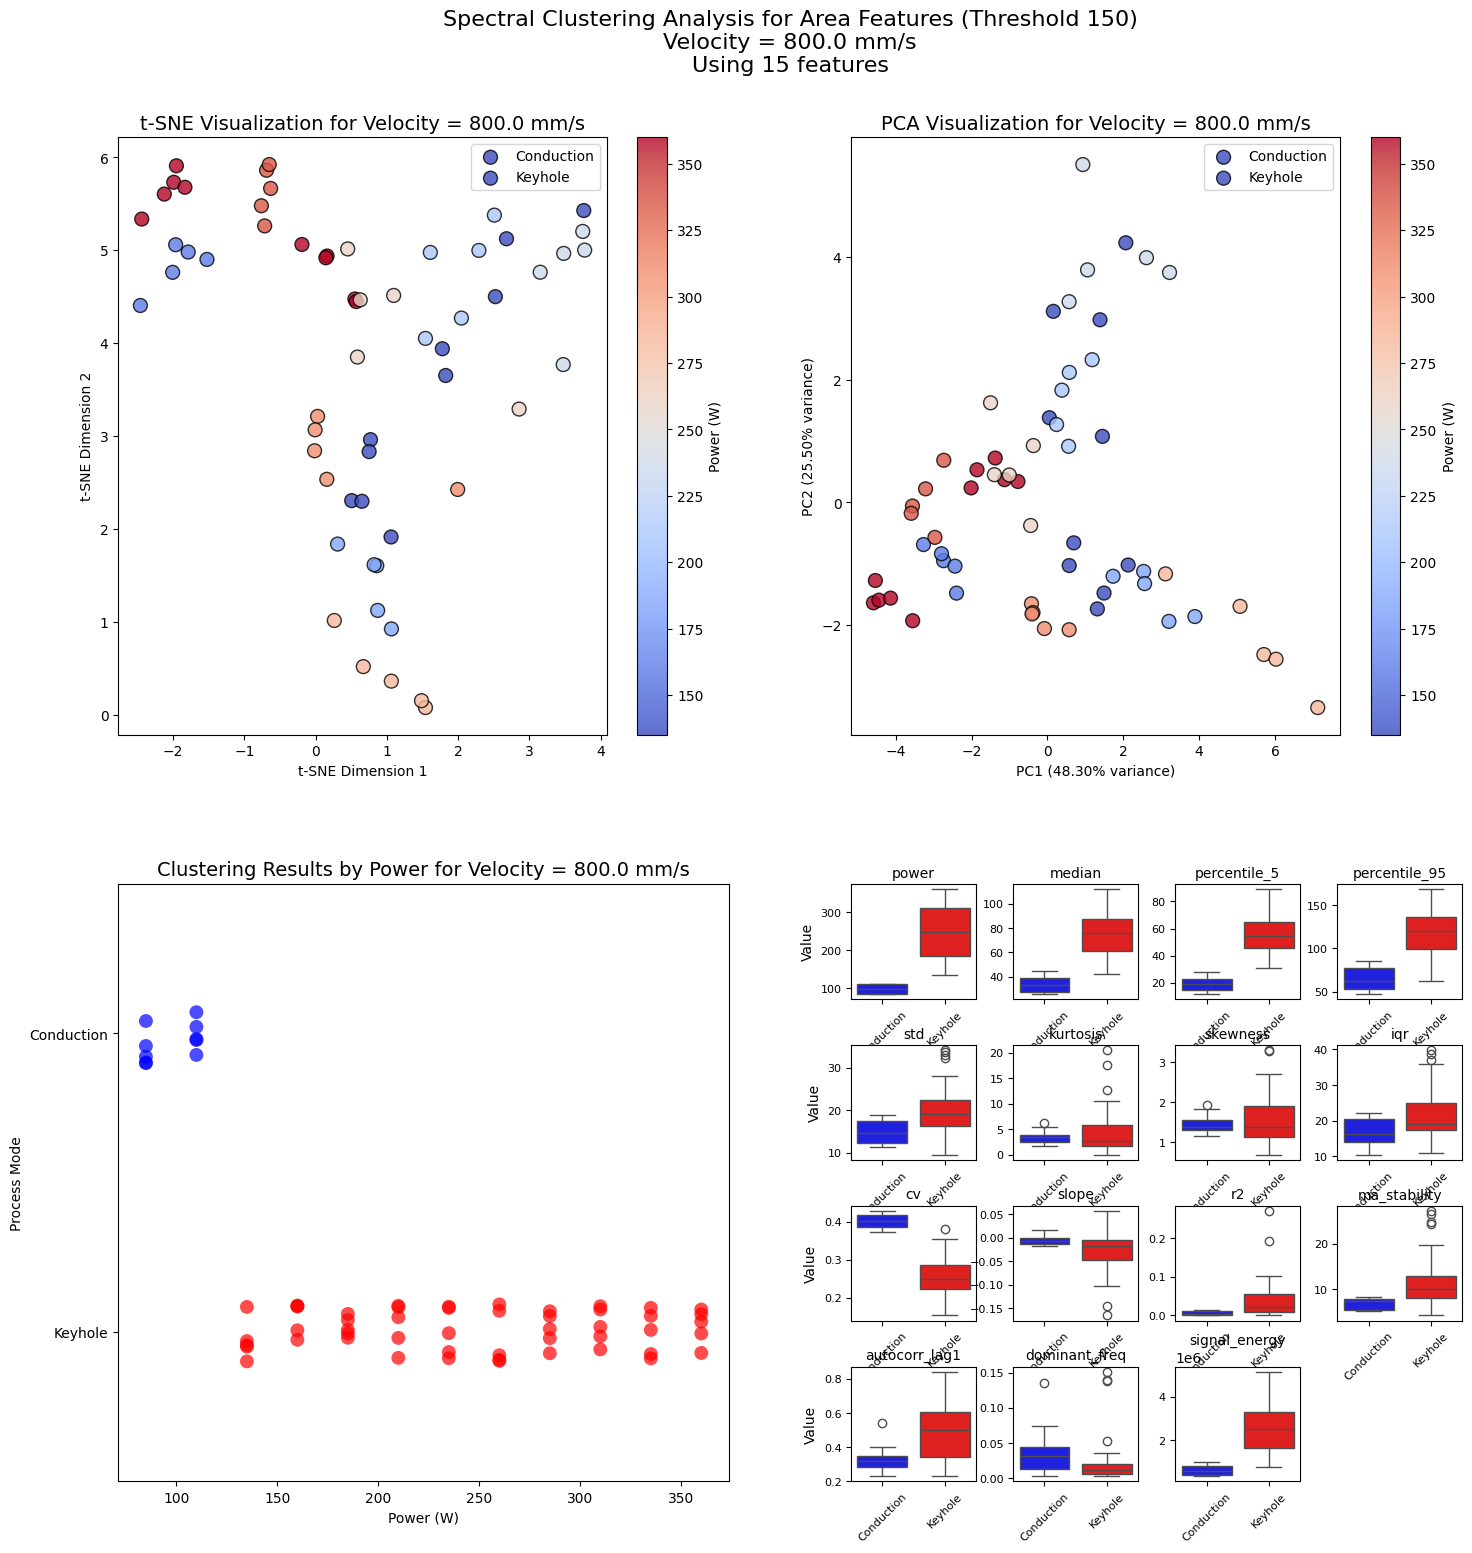

In [63]:
fig = spectral_clustering_analysis(
    features_data=features_data,
    velocity_value=800.0,
    selected_features=selected_features,
    feature_type='area',
    threshold=150
)

[[ 1.59325501e+00  2.62650019e+00  1.89342477e+00  2.55533331e+00
   1.48807404e+00 -1.30274863e+00 -2.01477666e+00  2.95345006e+00
  -2.79121601e-01 -7.79471219e-01 -1.02286547e-01  1.97518447e+00
   1.29093291e+00 -3.57053754e-01  2.98449181e+00]
 [ 1.59325501e+00  1.74883305e+00  1.43054590e+00  1.44164558e+00
   1.09533117e+00 -1.54738040e-01 -1.14585953e-01  1.10754377e+00
  -1.22120250e-01 -1.76788375e-01 -5.54238010e-01  1.75781774e+00
   1.18089725e+00 -6.61330065e-01  1.83521049e+00]
 [ 1.59325501e+00  1.45627733e+00  1.35548446e+00  1.09361816e+00
   5.71563035e-01 -8.40930363e-01 -9.15427249e-01  1.35366461e+00
  -4.56192161e-01 -7.44360184e-01  1.11446271e-01  7.97104067e-01
   1.04898399e+00 -4.00521798e-01  1.61050710e+00]
 [ 1.59325501e+00  1.94387019e+00  1.43054590e+00  1.62958038e+00
   1.42740930e+00  1.14711146e+00  6.96502044e-01  1.59978545e+00
   2.31938559e-02 -6.65353553e-01 -2.07994066e-01  1.54518300e+00
   1.69757532e+00 -3.55513547e-01  2.09227668e+00]
 [ 1

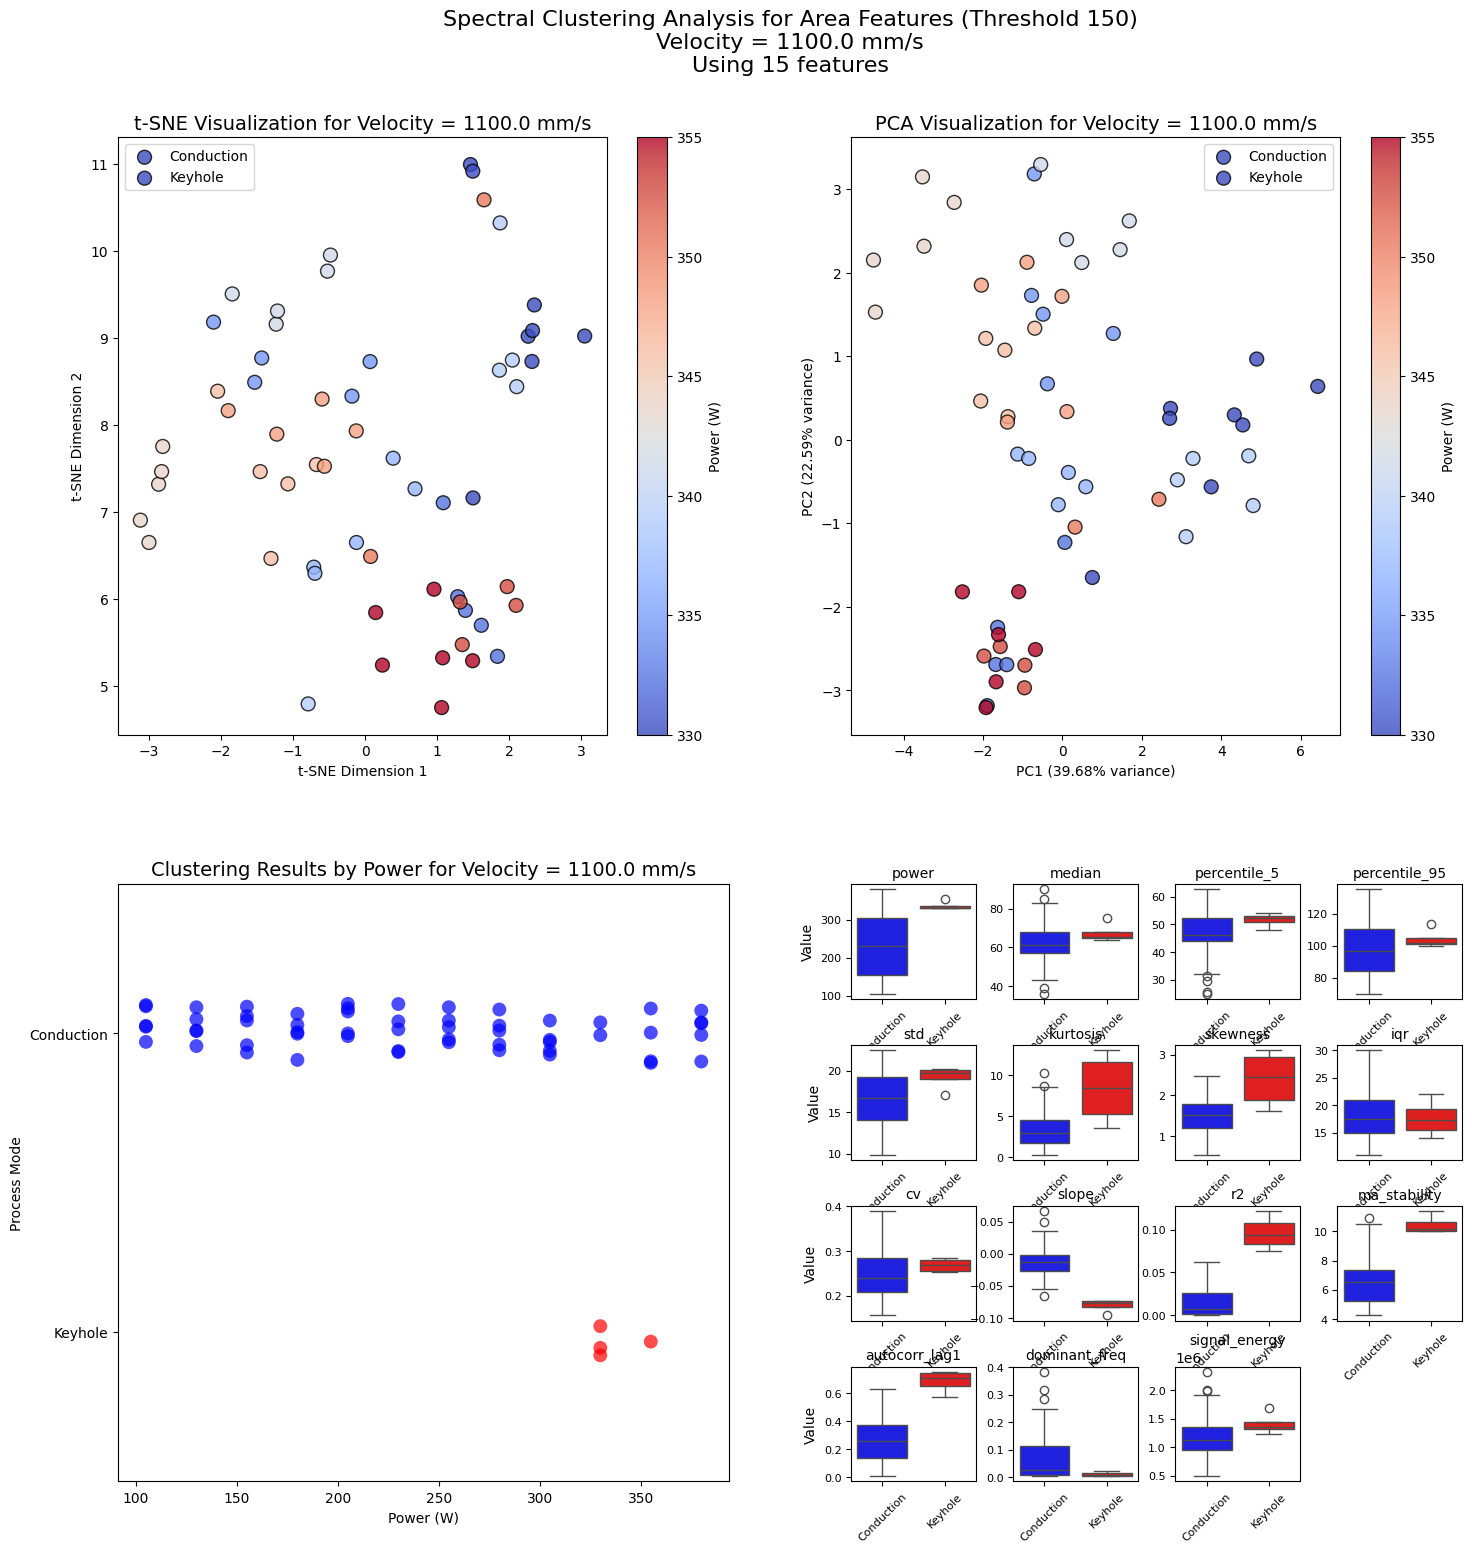

In [64]:
# Run clustering 
fig = spectral_clustering_analysis(
    features_data, 
    velocity_value=1100.0, 
    feature_type='area',
    threshold=150,
    standardize=True
)